# 07 — Final Model Evaluation and Feature Importance

Evaluate the stage-06 validation-selected pipeline on three held-out turbines. Use the saved training-fitted checkpoint and frozen threshold without refitting, so the threshold still applies to the model that produced the validation scores. Earlier exploratory test exposure is disclosed: these results are a descriptive held-out evaluation, not fresh independent confirmation.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (average_precision_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")
project_root = Path.cwd()
if not (project_root / "data" / "processed").exists():
    project_root = project_root.parent
data_dir = project_root / "data" / "processed"
results_dir = project_root / "reports" / "model_results"
figures_dir = project_root / "reports" / "figures"
models_dir = project_root / "models"
for directory in [results_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)
import sys
sys.path.insert(0, str(project_root))
from src.modeling.artifacts import check_splits, verify_manifest, write_manifest


## 1. Load and Verify Frozen Selection

Verify the checkpoint, feature schema, and split fingerprints before evaluation.

In [2]:
verify_manifest(project_root, models_dir / "06_selection_manifest.json")
selection = json.loads((models_dir / "06_selected_threshold.json").read_text())
selected_model_name = selection["model"]
frozen_threshold = float(selection["threshold"])
frames = check_splits(project_root)
selected_features = pd.read_csv(results_dir / "04_selected_features.csv")["feature"].tolist()
if selection["representation"] == "ann":
    from tensorflow import keras
    from src.modeling.neural_networks import load_data, dataset
    arrays = load_data(project_root)
    final_pipeline = keras.models.load_model(project_root / selection["model_path"])
    test_df = pd.read_csv(data_dir / "03_test_metadata.csv", parse_dates=["timestamp"])
    X_test = arrays["X_test"]
    X_validation = arrays["X_validation"]
    y_validation = arrays["y_validation"]
    fitted_preprocessor = joblib.load(models_dir / "neural_network_comparison/preprocessor.joblib")
    def predict_probability(X):
        return final_pipeline.predict(dataset(X), verbose=0).ravel()
else:
    final_pipeline = joblib.load(project_root / selection["model_path"])
    test_df = frames["test"]
    X_test = test_df[selected_features]
    X_validation = frames["validation"][selected_features]
    y_validation = frames["validation"]["failure"].to_numpy()
    def predict_probability(X):
        return final_pipeline.predict_proba(X)[:, 1]
print("Frozen model:", selected_model_name)
print("Frozen threshold:", frozen_threshold)
print("Test turbines:", sorted(test_df["turbine_id"].unique()))


Frozen model: XGBoost
Frozen threshold: 0.015
Test turbines: ['T002', 'T013', 'T014']


## 2. Preserve the Selected Checkpoint

No refit or threshold change occurs after validation selection.

In [3]:
import shutil
suffix = ".keras" if selection["representation"] == "ann" else ".joblib"
final_model_path = models_dir / ("07_final_model" + suffix)
shutil.copy2(project_root / selection["model_path"], final_model_path)
(models_dir / "07_final_selection.json").write_text(json.dumps(selection, indent=2))
print("Saved final checkpoint:", final_model_path)


Saved final checkpoint: /Users/namees.local/Desktop/Wind Turbine Failure Detection/models/07_final_model.joblib


## 3. Held-Out-Turbine Test Evaluation

Apply the frozen validation-selected threshold. Test outcomes do not change the selection.

In [4]:
y_test = test_df["failure"].astype("int8").copy()
test_probabilities = predict_probability(X_test)
test_predictions = (test_probabilities >= frozen_threshold).astype("int8")
test_metrics = pd.Series({"model": selected_model_name, "threshold": frozen_threshold, "rows": len(y_test), "failure_count": int(y_test.sum()), "failure_prevalence_pct": y_test.mean() * 100, "recall": recall_score(y_test, test_predictions), "precision": precision_score(y_test, test_predictions, zero_division=0), "f1": f1_score(y_test, test_predictions), "pr_auc": average_precision_score(y_test, test_probabilities), "roc_auc": roc_auc_score(y_test, test_probabilities), "predicted_positive_pct": test_predictions.mean() * 100})
display(test_metrics.to_frame("test_value"))
test_report = pd.DataFrame(classification_report(y_test, test_predictions, target_names=["normal", "failure"], output_dict=True, zero_division=0)).T
display(test_report)

,test_value
model,XGBoost
threshold,0.0150
rows,26352
failure_count,591
failure_prevalence_pct,2.2427
recall,0.9915
precision,0.5431
f1,0.7018
pr_auc,0.8647
roc_auc,0.9965


,precision,recall,f1-score,support
normal,0.9998,0.9809,0.9902,"25,761.0000"
failure,0.5431,0.9915,0.7018,591.0000
accuracy,0.9811,0.9811,0.9811,0.9811
macro avg,0.7714,0.9862,0.8460,"26,352.0000"
weighted avg,0.9896,0.9811,0.9838,"26,352.0000"


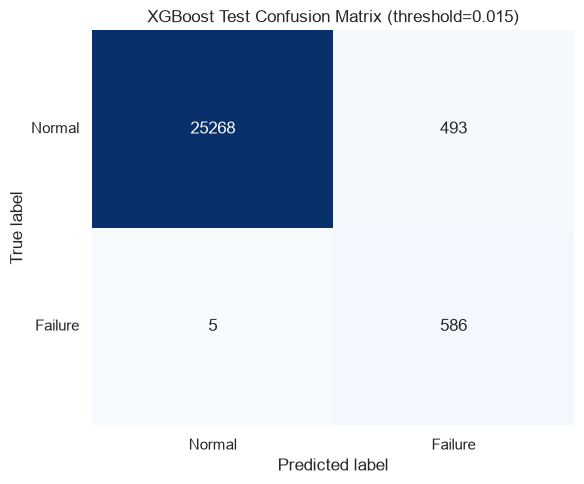

{'true_negatives': 25268, 'false_positives': 493, 'false_negatives': 5, 'true_positives': 586}


In [5]:
matrix = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = matrix.ravel()
fig, axis = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
axis.set(title=f"{selected_model_name} Test Confusion Matrix (threshold={frozen_threshold:.3f})", xlabel="Predicted label", ylabel="True label")
axis.set_xticklabels(["Normal", "Failure"]); axis.set_yticklabels(["Normal", "Failure"], rotation=0)
fig.tight_layout()
confusion_path = figures_dir / "07_final_test_confusion_matrix.png"
fig.savefig(confusion_path, dpi=160, bbox_inches="tight")
plt.show()
print({"true_negatives": int(tn), "false_positives": int(fp), "false_negatives": int(fn), "true_positives": int(tp)})

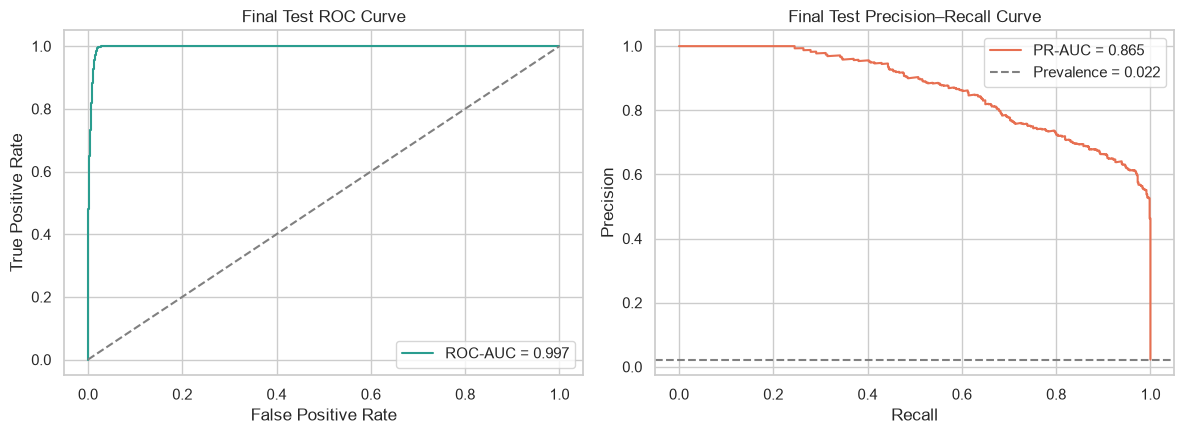

In [6]:
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_test, test_probabilities)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color="#2a9d8f", label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set(title="Final Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].plot(curve_recall, curve_precision, color="#e76f51", label=f"PR-AUC = {test_metrics['pr_auc']:.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label=f"Prevalence = {y_test.mean():.3f}")
axes[1].set(title="Final Test Precision–Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.legend()
fig.tight_layout()
curves_path = figures_dir / "07_final_test_roc_pr_curves.png"
fig.savefig(curves_path, dpi=160, bbox_inches="tight")
plt.show()

## 4. Operational Test Diagnostics

Row-level metrics are supplemented with turbine-day alert burden and failure-episode detection. A test failure episode is a consecutive per-turbine run of `failure=1` records at 10-minute cadence; an episode counts as detected if at least one of its records is predicted positive.

In [7]:
test_predictions_frame = test_df[["source_index", "timestamp", "turbine_id", "failure"]].copy()
test_predictions_frame["failure_probability"] = test_probabilities
test_predictions_frame["prediction"] = test_predictions
test_predictions_frame = test_predictions_frame.sort_values(["turbine_id", "timestamp"])
previous_failure = test_predictions_frame.groupby("turbine_id")["failure"].shift(fill_value=0)
time_gap_minutes = test_predictions_frame.groupby("turbine_id")["timestamp"].diff().dt.total_seconds().div(60)
new_episode = test_predictions_frame["failure"].eq(1) & (previous_failure.ne(1) | time_gap_minutes.ne(10))
test_predictions_frame["failure_episode_id"] = new_episode.groupby(test_predictions_frame["turbine_id"]).cumsum().where(test_predictions_frame["failure"].eq(1))
episode_summary = test_predictions_frame.dropna(subset=["failure_episode_id"]).groupby(["turbine_id", "failure_episode_id"]).agg(start=("timestamp", "min"), end=("timestamp", "max"), records=("failure", "size"), detected=("prediction", "max")).reset_index()
episode_recall = episode_summary["detected"].mean()
turbine_days = test_predictions_frame.assign(day=test_predictions_frame["timestamp"].dt.date).groupby(["turbine_id", "day"]).size().shape[0]
false_alerts_per_turbine_day = fp / turbine_days
operational_metrics = pd.Series({"failure_episodes": len(episode_summary), "detected_episodes": int(episode_summary["detected"].sum()), "episode_recall": episode_recall, "false_positives": int(fp), "turbine_days": turbine_days, "false_positive_records_per_turbine_day": false_alerts_per_turbine_day})
display(operational_metrics.to_frame("test_value"))

,test_value
failure_episodes,43.0000
detected_episodes,43.0000
episode_recall,1.0000
false_positives,493.0000
turbine_days,183.0000
false_positive_records_per_turbine_day,2.6940


## 5. Selected-Model Feature Importance

Tree models report their fitted impurity/gain importances. A neural winner reports permutation importance on a fixed validation sample, measured as the decrease in PR-AUC. Permutation uses transformed inputs, so PCA components are not individual physical sensors. Neither measure establishes causation.

,feature,importance,rank,cumulative_importance,method
0,drivetrain_vibration_rms_mmps_past_3h_mean,0.4491,1,0.4491,Fitted tree importance
1,yaw_misalignment_cos,0.1786,2,0.6276,Fitted tree importance
2,drivetrain_vibration_rms_mmps_past_1h_mean,0.1250,3,0.7527,Fitted tree importance
3,tower_vibration_mmps,0.1053,4,0.8579,Fitted tree importance
4,vib_fft_gearmesh,0.0214,5,0.8793,Fitted tree importance
5,drivetrain_vibration_rms_mmps,0.0169,6,0.8962,Fitted tree importance
6,drivetrain_vibration_rms_mmps_lag1,0.0109,7,0.9071,Fitted tree importance
7,fft_spread,0.0109,8,0.9180,Fitted tree importance
8,gearmesh_sideband_ratio,0.0070,9,0.9249,Fitted tree importance
9,vib_fft_bearing_bpfo,0.0050,10,0.9299,Fitted tree importance


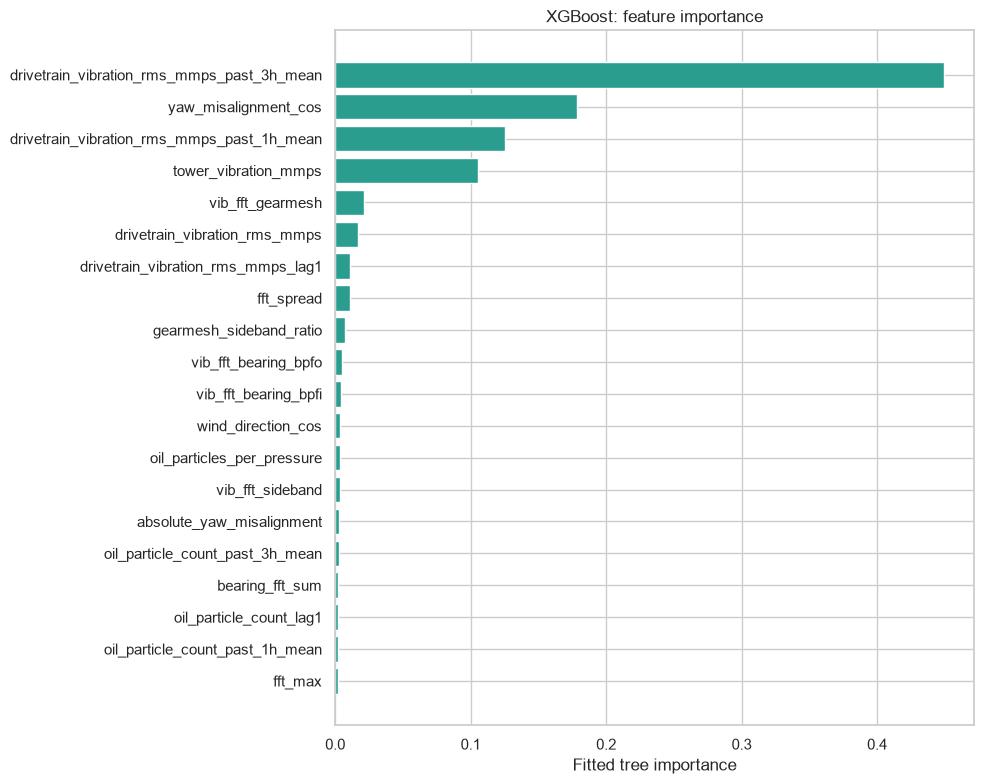

In [8]:
if selection["representation"] == "engineered":
    fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
    transformed_feature_names = fitted_preprocessor.get_feature_names_out()
    importance_values = final_pipeline.named_steps["model"].feature_importances_
    importance_method = "Fitted tree importance"
else:
    transformed_feature_names = fitted_preprocessor.get_feature_names_out()
    rng = np.random.default_rng(42)
    indices = rng.choice(len(X_validation), size=min(3000, len(X_validation)), replace=False)
    sample = X_validation[indices].copy()
    labels = y_validation[indices]
    reference = average_precision_score(labels, predict_probability(sample))
    importance_values = []
    for column in range(sample.shape[1]):
        scores = []
        for repeat in range(3):
            permuted = sample.copy()
            permuted[:, column] = rng.permutation(permuted[:, column])
            scores.append(reference - average_precision_score(labels, predict_probability(permuted)))
        importance_values.append(float(np.mean(scores)))
    importance_method = "Validation permutation PR-AUC decrease"
feature_importance = pd.DataFrame({"feature": transformed_feature_names, "importance": importance_values}).sort_values("importance", ascending=False).reset_index(drop=True)
feature_importance["rank"] = np.arange(1, len(feature_importance) + 1)
feature_importance["cumulative_importance"] = feature_importance["importance"].cumsum()
feature_importance["method"] = importance_method
display(feature_importance.head(20))
fig, axis = plt.subplots(figsize=(10, 8))
plot_data = feature_importance.head(20).sort_values("importance")
axis.barh(plot_data["feature"], plot_data["importance"], color="#2a9d8f")
axis.set(title=f"{selected_model_name}: feature importance", xlabel=importance_method)
fig.tight_layout()
importance_path = figures_dir / "07_final_feature_importance.png"
fig.savefig(importance_path, dpi=160, bbox_inches="tight")
plt.show()


### Original Versus Engineered Features and Source-Sensor Families

The detailed table below preserves the model's actual inputs while identifying whether each input came directly from the source CSV or was engineered in Step 04. A second view sums importance within physical source-sensor families. This avoids presenting several correlated rolling versions of one sensor as independent business findings.

,rank,feature,feature_type,source_sensor_family,importance
0,1,drivetrain_vibration_rms_mmps_past_3h_mean,Engineered,Drivetrain vibration,0.4491
1,2,yaw_misalignment_cos,Engineered,Yaw misalignment,0.1786
2,3,drivetrain_vibration_rms_mmps_past_1h_mean,Engineered,Drivetrain vibration,0.1250
3,4,tower_vibration_mmps,Original,Tower vibration,0.1053
4,5,vib_fft_gearmesh,Original,FFT vibration signals,0.0214
5,6,drivetrain_vibration_rms_mmps,Original,Drivetrain vibration,0.0169
6,7,drivetrain_vibration_rms_mmps_lag1,Engineered,Drivetrain vibration,0.0109
7,8,fft_spread,Engineered,FFT vibration signals,0.0109
8,9,gearmesh_sideband_ratio,Engineered,FFT vibration signals,0.0070
9,10,vib_fft_bearing_bpfo,Original,FFT vibration signals,0.0050


,rank,source_sensor_family,importance,cumulative_importance
0,1,Drivetrain vibration,0.6048,0.6048
1,2,Yaw misalignment,0.1823,0.7871
2,3,Tower vibration,0.1053,0.8924
3,4,FFT vibration signals,0.0578,0.9502
4,5,Oil particle count,0.0129,0.9631
5,6,Wind direction,0.0063,0.9694
6,7,Gearbox temperature,0.0063,0.9757
7,8,Main-bearing temperature,0.0060,0.9817
8,9,Generator temperature,0.0055,0.9872
9,10,Oil pressure,0.0041,0.9913


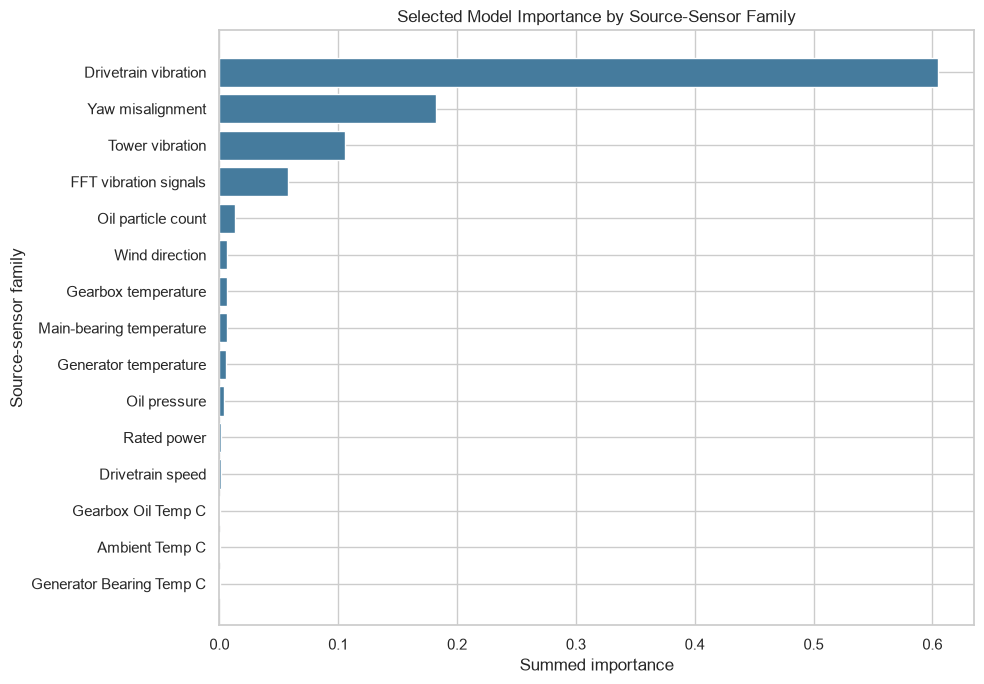

In [9]:
raw_columns = set(pd.read_csv(project_root / "data" / "raw" / "wind_turbine_detection.csv", nrows=0).columns)
def feature_origin(feature):
    return "Original" if feature in raw_columns or feature.startswith("rated_power_kW_") else "Engineered"

def sensor_family(feature):
    if "drivetrain_vibration" in feature or feature == "vibration_per_rotor_rpm": return "Drivetrain vibration"
    if feature.startswith("tower_vibration"): return "Tower vibration"
    if feature.startswith("vib_fft_") or feature.startswith("fft_") or feature in {"bearing_fft_sum", "gearmesh_sideband_ratio"}: return "FFT vibration signals"
    if "yaw_misalignment" in feature: return "Yaw misalignment"
    if "wind_direction" in feature: return "Wind direction"
    if "oil_particle" in feature: return "Oil particle count"
    if "oil_pressure" in feature: return "Oil pressure"
    if "gearbox_bearing_temp" in feature or feature in {"gearbox_temp_rise", "gearbox_nacelle_temp_gap"}: return "Gearbox temperature"
    if "main_bearing_temp" in feature: return "Main-bearing temperature"
    if "generator_winding_temp" in feature or feature == "winding_bearing_temp_gap": return "Generator temperature"
    if feature in {"generator_speed_rpm", "rotor_speed_rpm", "generator_rotor_ratio", "rotor_stopped"}: return "Drivetrain speed"
    if feature in {"power_output_kW", "capacity_factor", "positive_power", "near_rated_operation"}: return "Power output"
    if feature.startswith("rated_power_kW"): return "Rated power"
    return feature.replace("_", " ").title()

importance_interpretation = feature_importance.copy()
importance_interpretation["feature_type"] = importance_interpretation["feature"].map(feature_origin)
importance_interpretation["source_sensor_family"] = importance_interpretation["feature"].map(sensor_family)
display(importance_interpretation.head(20)[["rank", "feature", "feature_type", "source_sensor_family", "importance"]])
family_importance = importance_interpretation.groupby("source_sensor_family", as_index=False)["importance"].sum().sort_values("importance", ascending=False).reset_index(drop=True)
family_importance["rank"] = np.arange(1, len(family_importance) + 1)
family_importance["cumulative_importance"] = family_importance["importance"].cumsum()
display(family_importance.head(15)[["rank", "source_sensor_family", "importance", "cumulative_importance"]])
fig, axis = plt.subplots(figsize=(10, 7))
family_plot = family_importance.head(15).sort_values("importance")
axis.barh(family_plot["source_sensor_family"], family_plot["importance"], color="#457b9d")
axis.set(title="Selected Model Importance by Source-Sensor Family", xlabel="Summed importance", ylabel="Source-sensor family")
fig.tight_layout()
family_importance_path = figures_dir / "07_final_sensor_family_importance.png"
fig.savefig(family_importance_path, dpi=160, bbox_inches="tight")
plt.show()
importance_interpretation.to_csv(results_dir / "07_final_importance_interpretation.csv", index=False)
family_importance.to_csv(results_dir / "07_final_sensor_family_importance.csv", index=False)

#### Interpretation

Use the executed tables above to identify the leading inputs and sensor families. Importance is specific to the selected model and input representation; neural permutation scores are not percentages.

## 6. Save Final Results

In [10]:
pd.DataFrame([test_metrics.to_dict()]).to_csv(results_dir / "07_final_test_metrics.csv", index=False)
test_report.reset_index(names="class").to_csv(results_dir / "07_final_test_classification_report.csv", index=False)
operational_metrics.to_frame().T.to_csv(results_dir / "07_final_test_operational_metrics.csv", index=False)
episode_summary.to_csv(results_dir / "07_final_test_episode_results.csv", index=False)
feature_importance.to_csv(results_dir / "07_final_feature_importance.csv", index=False)
test_predictions_frame.to_csv(results_dir / "07_final_test_predictions.csv", index=False)
print("Final checkpoint:", final_model_path.relative_to(project_root))
print("Top feature:", feature_importance.iloc[0]["feature"])
print("Final result files saved and test predictions remain traceable by source row, timestamp, and turbine.")
result_paths = [results_dir / name for name in ["07_final_test_metrics.csv", "07_final_test_operational_metrics.csv", "07_final_feature_importance.csv", "07_final_sensor_family_importance.csv", "07_final_importance_interpretation.csv", "07_final_test_classification_report.csv"]]
write_manifest(project_root, result_paths + [models_dir / "06_selection_manifest.json", models_dir / "07_final_selection.json", final_model_path], models_dir / "07_results_manifest.json")


Final checkpoint: models/07_final_model.joblib
Top feature: drivetrain_vibration_rms_mmps_past_3h_mean
Final result files saved and test predictions remain traceable by source row, timestamp, and turbine.


## Key Findings Recap

- Evaluated the frozen XGBoost checkpoint at threshold 0.015 without refitting.
- The held-out-turbine test set contains 26,352 rows and 591 failures.
- Test recall was 0.9915, precision 0.5431, F1 0.7018, PR-AUC 0.8647, and ROC-AUC 0.9965.
- Detected 43 of 43 episodes; false-positive burden was 2.6940 records per turbine-day.
- The leading input was drivetrain_vibration_rms_mmps_past_3h_mean, using fitted tree importance.
- Earlier exploratory test exposure means these results are not fresh independent confirmation.
- Generic final-model artifacts and result fingerprints support reporting regardless of the winning family.